# Truth vs Degraded Catalog: Angular Power Spectra Comparison

Compares galaxy clustering $C_\ell$ from:
- **Truth** catalog (`dp2_23p5_nmin500_truth_combined_mask`) — noise-free simulation magnitudes
- **Degraded** catalog (`dp2_23p5_nmin500_deproj_combined_mask`) — observed-condition photometry with noise + deprojection


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sacc

# ── copy of load_cls from txpipe_util.ipynb ───────────────────────────────────
def load_cls(sacc_file):
    """Load all C_ell measurements grouped by data type and bin pair.

    Returns
    -------
    s       : sacc.Sacc
    results : dict  { data_type: [(t1, t2, ell, cl, err), ...] }
    """
    s = sacc.Sacc.load_fits(sacc_file)
    data_types = set(dp.data_type for dp in s.data)
    print(f"Data types found: {sorted(data_types)}")

    results = {}
    for dt in sorted(data_types):
        tracers = s.get_tracer_combinations(dt)
        entries = []
        for (t1, t2) in tracers:
            ell, cl = s.get_ell_cl(dt, t1, t2)
            try:
                indices = s.indices(dt, (t1, t2))
                cov = s.covariance.dense[np.ix_(indices, indices)]
                err = np.sqrt(np.diag(cov))
            except Exception:
                err = np.zeros_like(cl)
            entries.append((t1, t2, ell, cl, err))
        results[dt] = entries

    return s, results


def parse_bin_index(tracer_name):
    """Extract integer bin index from a tracer name like 'lens_2'."""
    parts = tracer_name.rsplit("_", 1)
    try:
        return int(parts[-1])
    except ValueError:
        return 0


def bin_label(tracer_name):
    """Turn 'lens_0' into 'Lens 0' etc."""
    parts = tracer_name.rsplit("_", 1)
    if len(parts) == 2:
        return f"{parts[0].capitalize()} {parts[1]}"
    return tracer_name

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
BASE = "data/outputs"

sacc_truth    = f"{BASE}/dp2_24p5_nmin500_truth_combined_mask/summary_statistics_fourier.sacc"
sacc_degraded = f"{BASE}/dp2_24p5_nmin500_deproj_combined_mask/summary_statistics_fourier.sacc"

output_dir = "data/outputs"   # set to None to only show interactively
output_dir = None

In [3]:
# ── load both SACC files ──────────────────────────────────────────────────────
print("Loading truth catalog Cls...")
s_truth, res_truth = load_cls(sacc_truth)

print("\nLoading degraded catalog Cls...")
s_deg, res_deg = load_cls(sacc_degraded)

Loading truth catalog Cls...
Data types found: ['galaxy_density_cl']

Loading degraded catalog Cls...
Data types found: ['galaxy_density_cl']


In [4]:
def compare_cls_overlay(
    res_truth,
    res_degraded,
    data_type="galaxy_density_cl",
    output_path=None,
):
    """Overlay truth and degraded C_ell on a lower-triangular bin-pair grid.

    Both curves are drawn with error bars extracted from the SACC covariance.
    The degraded points are nudged by 4% in ell for visual separation.

    Parameters
    ----------
    res_truth, res_degraded : dict
        Output of load_cls (the results dict).
    data_type : str
        Data type key to plot (e.g. 'galaxy_density_cl').
    output_path : str or None
        If given, save the figure there; otherwise show interactively.
    """
    entries_t = res_truth.get(data_type, [])
    entries_d = res_degraded.get(data_type, [])
    if not entries_t or not entries_d:
        print(f"No data for type '{data_type}'")
        return

    all_tracers = sorted(
        set(t for t1, t2, *_ in entries_t for t in (t1, t2)),
        key=lambda t: (t.rsplit("_", 1)[0], parse_bin_index(t)),
    )
    nbin = len(all_tracers)
    tidx = {t: i for i, t in enumerate(all_tracers)}

    def make_lookup(entries):
        return {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries}

    lut_t = make_lookup(entries_t)
    lut_d = make_lookup(entries_d)

    fig, axes = plt.subplots(
        nbin, nbin,
        figsize=(4.5 * nbin, 4.0 * nbin),
        squeeze=False,
    )
    fig.suptitle(
        r"$\ell(\ell+1)C_\ell^{gg}/2\pi$  — Truth vs Degraded",
        fontsize=15, y=1.01,
    )

    for r in range(nbin):
        for c in range(nbin):
            axes[r][c].set_visible(False)

    for t1, t2, *_ in entries_t:
        key = (t1, t2)
        if key not in lut_d:
            print(f"  Pair {key} missing from degraded — skipping")
            continue

        ell_t, cl_t, err_t = lut_t[key]
        ell_d, cl_d, err_d = lut_d[key]

        i = tidx[t1]
        j = tidx[t2]
        if i < j:
            i, j = j, i

        ax = axes[i][j]
        ax.set_visible(True)

        fac_t = ell_t * (ell_t + 1) / (2 * np.pi)
        fac_d = ell_d * (ell_d + 1) / (2 * np.pi)
        y_t, ye_t = fac_t * cl_t, fac_t * err_t
        y_d, ye_d = fac_d * cl_d, fac_d * err_d

        # Truth: solid blue circles with error bars
        ax.errorbar(
            ell_t, y_t, yerr=ye_t,
            fmt="o", ms=4, lw=1.5, capsize=3, capthick=1.2,
            color="#4363D8", label="Truth", zorder=3,
        )

        # Degraded: dashed red squares, nudged 4% in ell to avoid overlap
        ax.errorbar(
            ell_d * 1.04, y_d, yerr=ye_d,
            fmt="s", ms=4, lw=1.5, capsize=3, capthick=1.2,
            color="#E6194B", label="Degraded", zorder=3,
            linestyle="--",
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", ls=":", alpha=0.35)

        title = (
            f"{bin_label(t1)} (auto)"
            if t1 == t2
            else f"{bin_label(t1)} × {bin_label(t2)}"
        )
        ax.set_title(title, fontsize=10, fontweight="bold" if t1 == t2 else "normal")
        ax.set_xlabel(r"$\ell$", fontsize=10)
        ax.set_ylabel(r"$\ell(\ell+1)C_\ell/2\pi$", fontsize=9)
        ax.legend(fontsize=8, framealpha=0.8)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()


def compare_cls_ratio(
    res_truth,
    res_degraded,
    data_type="galaxy_density_cl",
    output_path=None,
):
    """Plot the ratio degraded / truth for each bin pair.

    Error bars are propagated assuming truth and degraded are independent.
    A ratio consistent with 1 means the noise has no effect on the clustering.
    """
    entries_t = res_truth.get(data_type, [])
    entries_d = res_degraded.get(data_type, [])
    if not entries_t or not entries_d:
        print(f"No data for type '{data_type}'")
        return

    all_tracers = sorted(
        set(t for t1, t2, *_ in entries_t for t in (t1, t2)),
        key=lambda t: (t.rsplit("_", 1)[0], parse_bin_index(t)),
    )
    nbin = len(all_tracers)
    tidx = {t: i for i, t in enumerate(all_tracers)}

    lut_t = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_t}
    lut_d = {(t1, t2): (ell, cl, err) for t1, t2, ell, cl, err in entries_d}

    fig, axes = plt.subplots(
        nbin, nbin,
        figsize=(4.5 * nbin, 3.5 * nbin),
        squeeze=False,
    )
    fig.suptitle(
        r"$C_\ell^{gg}$ ratio: Degraded / Truth",
        fontsize=15, y=1.01,
    )

    for r in range(nbin):
        for c in range(nbin):
            axes[r][c].set_visible(False)

    for t1, t2, *_ in entries_t:
        key = (t1, t2)
        if key not in lut_d:
            continue

        ell_t, cl_t, err_t = lut_t[key]
        ell_d, cl_d, err_d = lut_d[key]

        i = tidx[t1]
        j = tidx[t2]
        if i < j:
            i, j = j, i

        ax = axes[i][j]
        ax.set_visible(True)

        ratio = np.where(np.abs(cl_t) > 0, cl_d / cl_t, np.nan)
        with np.errstate(invalid="ignore", divide="ignore"):
            frac_err = np.sqrt(
                np.where(cl_d != 0, (err_d / cl_d) ** 2, 0)
                + np.where(cl_t != 0, (err_t / cl_t) ** 2, 0)
            )
        ratio_err = np.abs(ratio) * frac_err

        ax.axhline(1.0, color="grey", lw=1.0, ls="--")
        ax.errorbar(
            ell_t, ratio, yerr=ratio_err,
            fmt="o", ms=4, lw=1.5, capsize=3, capthick=1.2,
            color="#3CB44B",
        )

        ax.set_xscale("log")
        ax.grid(True, which="both", ls=":", alpha=0.35)

        title = (
            f"{bin_label(t1)} (auto)"
            if t1 == t2
            else f"{bin_label(t1)} × {bin_label(t2)}"
        )
        ax.set_title(title, fontsize=10, fontweight="bold" if t1 == t2 else "normal")
        ax.set_xlabel(r"$\ell$", fontsize=10)
        ax.set_ylabel(r"$C_\ell^{\rm deg} / C_\ell^{\rm truth}$", fontsize=10)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {output_path}")
        plt.close()
    else:
        plt.show()

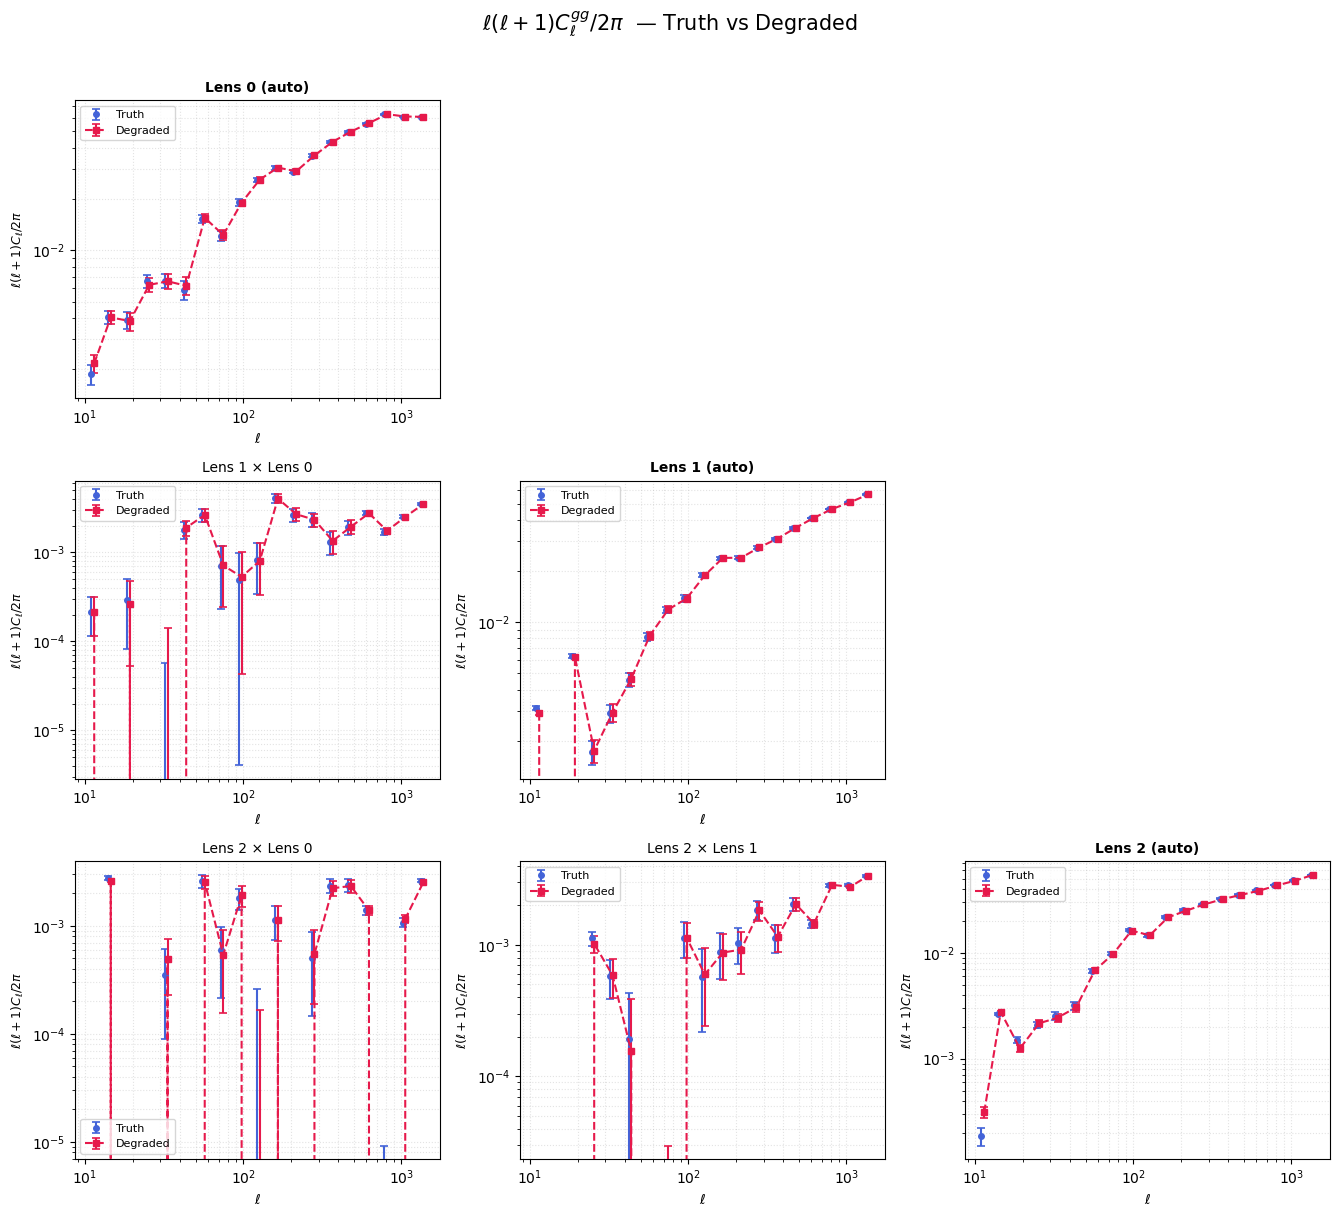

In [5]:
# ── overlay plot ──────────────────────────────────────────────────────────────
out_overlay = (
    f"{output_dir}/cls_truth_vs_degraded_overlay.png"
    if output_dir else None
)
compare_cls_overlay(res_truth, res_deg, output_path=out_overlay)

In [34]:
# ── ratio plot ────────────────────────────────────────────────────────────────
out_ratio = (
    f"{output_dir}/cls_truth_vs_degraded_ratio.png"
    if output_dir else None
)
compare_cls_ratio(res_truth, res_deg, output_path=out_ratio)

Saved: data/outputs/cls_truth_vs_degraded_ratio.png


## Degraded catalog n(z): mag_r ≤ 24.5 within footprint mask

Reads the eight degraded parquet files directly, applies a r-band magnitude cut
and a HEALPix footprint mask, then saves a normalised n(z) text file.

/tmp/ipykernel_788336/845642648.py:22: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  mask = hp.read_map(MASK_PATH, verbose=False).astype(bool)   # RING, nside=512


Mask: 103,084 valid pixels  (f_sky = 0.03277)
  [1/8] 24811  30,922,844 rows
  [2/8] 24812  20,488,206 rows
  [3/8] 24813  20,695,200 rows
  [4/8] 24814  20,618,535 rows
  [5/8] 24815  20,386,702 rows
  [6/8] 24816  20,617,519 rows
  [7/8] 24817  20,563,434 rows
  [8/8] 24818  30,725,640 rows

N total              : 185,018,080
N after mag_r <= 24.5: 137,134,326  (74.12%)
N after mask         : 104,471,348  (56.47%)

Sky coverage         : 1351.8 deg²  (f_sky = 0.03277)
Number density       : 21.4669 gal/arcmin²  =  77280.9 gal/deg²

Saved: data/nz_degraded_r24p5_masked.txt


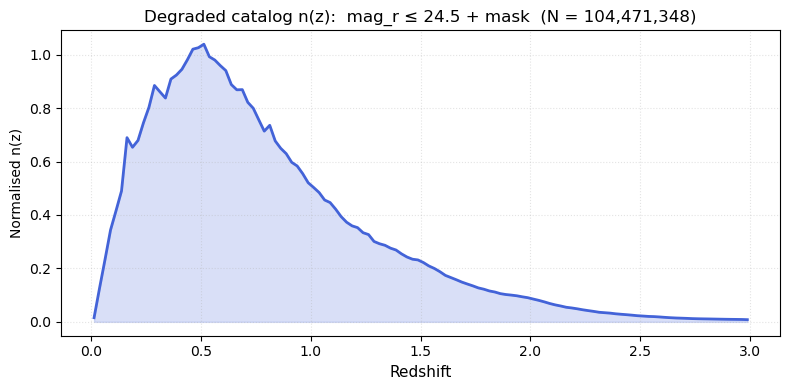

In [5]:
import pyarrow.parquet as pq
import healpy as hp
import numpy as np

DEGRADED_PQ_PATHS = [
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24811/output_deredden_lsst_obs_cond_dp2.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24812/output_deredden_lsst_obs_cond_dp2.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24813/output_deredden_lsst_obs_cond_dp2.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24814/output_deredden_lsst_obs_cond_dp2.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24815/output_deredden_lsst_obs_cond_dp2.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24816/output_deredden_lsst_obs_cond_dp2.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24817/output_deredden_lsst_obs_cond_dp2.pq",
    "/global/cfs/cdirs/lsst/groups/PZ/users/qhang/flagship_dp2/flagship_mock/Flagship/dp2_mock_run_flagship_gold_test/24818/output_deredden_lsst_obs_cond_dp2.pq",
]

MASK_PATH = "/pscratch/sd/a/anicola/DP2/data/masks/dp2_24p5_combined_mask_nmin=500_nside=512.fits"
MAGLIM    = 24.5
OUT_PATH  = "data/nz_degraded_r24p5_masked.txt"
READ_COLS = ["mag_r_lsst", "redshift", "ra", "dec"]

# ── load mask ─────────────────────────────────────────────────────────────────
mask = hp.read_map(MASK_PATH, verbose=False).astype(bool)   # RING, nside=512
print(f"Mask: {mask.sum():,} valid pixels  (f_sky = {mask.mean():.5f})")

# ── accumulate n(z) in chunks ─────────────────────────────────────────────────
z_edges = np.linspace(0.0, 3.0, 121)   # 120 bins, dz = 0.025
z_mid   = 0.5 * (z_edges[:-1] + z_edges[1:])
counts  = np.zeros(len(z_mid), dtype=np.int64)
n_total = n_maglim = n_final = 0

for file_idx, path in enumerate(DEGRADED_PQ_PATHS, 1):
    pf = pq.ParquetFile(path)
    file_count = 0
    for batch in pf.iter_batches(batch_size=100_000, columns=READ_COLS):
        df = batch.to_pandas()
        n_total   += len(df)
        file_count += len(df)
        sel_mag    = df["mag_r_lsst"].to_numpy() <= MAGLIM
        pix        = hp.ang2pix(512, df["ra"].to_numpy(), df["dec"].to_numpy(),
                                lonlat=True, nest=False)
        sel_mask   = mask[pix]
        sel        = sel_mag & sel_mask
        n_maglim  += int(sel_mag.sum())
        n_final   += int(sel.sum())
        h, _       = np.histogram(df.loc[sel, "redshift"], bins=z_edges)
        counts    += h
    print(f"  [{file_idx}/8] {path.split('/')[-2]}  {file_count:,} rows")

print(f"\nN total              : {n_total:,}")
print(f"N after mag_r <= {MAGLIM}: {n_maglim:,}  ({100*n_maglim/n_total:.2f}%)")
print(f"N after mask         : {n_final:,}  ({100*n_final/n_total:.2f}%)")

# ── sky coverage & number density ────────────────────────────────────────────
import healpy as _hp
pix_area_deg2   = _hp.nside2pixarea(512, degrees=True)
area_deg2       = float(mask.sum()) * pix_area_deg2
area_arcmin2    = area_deg2 * 3600.0
n_bar_arcmin2   = n_final / area_arcmin2   if area_arcmin2 > 0 else 0.0
n_bar_deg2      = n_final / area_deg2      if area_deg2    > 0 else 0.0
f_sky           = mask.mean()
print(f"\nSky coverage         : {area_deg2:.1f} deg²  (f_sky = {f_sky:.5f})")
print(f"Number density       : {n_bar_arcmin2:.4f} gal/arcmin²  =  {n_bar_deg2:.1f} gal/deg²")

# ── normalise ─────────────────────────────────────────────────────────────────
norm = np.trapezoid(counts, z_mid)
nz   = counts / norm if norm > 0 else counts.astype(float)

# ── save ──────────────────────────────────────────────────────────────────────
import os; os.makedirs("data", exist_ok=True)
header = (
    f"z_mid  n(z)  [normalised: int(n(z))dz=1]\n"
    f"maglim=mag_r_lsst<={MAGLIM}  mask={MASK_PATH.split('/')[-1]}\n"
    f"N_total={n_total}  N_maglim={n_maglim}  N_final={n_final}\n"
    f"area_deg2={area_deg2:.4f}  f_sky={f_sky:.6f}  "
    f"n_bar_arcmin2={n_bar_arcmin2:.6f}  n_bar_deg2={n_bar_deg2:.4f}"
)
np.savetxt(OUT_PATH, np.column_stack([z_mid, nz]), header=header)
print(f"\nSaved: {OUT_PATH}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z_mid, nz, color="#4363D8", lw=2)
ax.fill_between(z_mid, nz, alpha=0.2, color="#4363D8")
ax.set_xlabel("Redshift", fontsize=11)
ax.set_ylabel("Normalised n(z)", fontsize=10)
ax.set_title(
    f"Degraded catalog n(z):  mag_r \u2264 {MAGLIM} + mask  (N = {n_final:,})",
    fontsize=12,
)
ax.grid(True, ls=":", alpha=0.35)
plt.tight_layout()
plt.show()
